In [120]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [121]:
t_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

v_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

device = torch.device("mps" if torch.mps.is_available() else "cpu")


training_set = DataLoader(t_dataset, batch_size=64, shuffle=True)
validation_set = DataLoader(v_dataset, batch_size=128)


In [122]:
class Classifier(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 8, (5, 5)), # (8, 24, 24)
            nn.ReLU(),
            nn.MaxPool2d(2),         # (8, 12, 12)
            nn.Conv2d(8, 8, (3, 3)), # (8, 10, 10)
            nn.ReLU(),
            nn.MaxPool2d(2),         # (8, 5, 5)
            nn.Flatten(),
            nn.Linear(5 * 5 * 8, 10)
        )
        
        
    def forward(self, x):
        return self.model(x)

In [123]:
num_iter = 5
learning_rate = 1e-3
 
train_loss = []
train_accuracy = []
validation_loss = []
validation_accuracy = []
 
model = Classifier().to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [124]:
# TODO train the model, add accuracy
for epoch in range(num_iter):
    model.train()
    print(f"Epoch {epoch + 1} / {num_iter}")
    
    epoch_loss = 0
    correct_classified = 0
    total_examples = 0
    for xb, yb in training_set:
        x = xb.to(device)
        y = yb.to(device)
    
        
        logits = model(x)
        loss = loss_func(logits, y)
        
        correct_classified += (y == torch.argmax(logits, dim=1)).sum().item()
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        epoch_loss += loss.item()
        total_examples += x.shape[0]
    
    train_loss.append(epoch_loss / len(training_set))
    train_accuracy.append(correct_classified / total_examples)

Epoch 1 / 5
53776
60000
Epoch 2 / 5
58003
60000
Epoch 3 / 5
58428
60000
Epoch 4 / 5
58665
60000
Epoch 5 / 5
58832
60000


In [125]:
# TODO eval

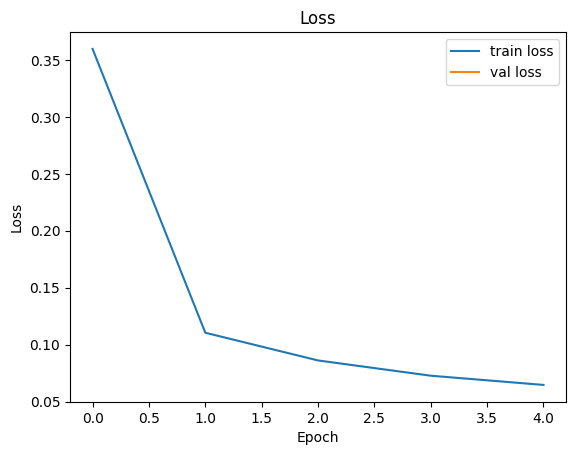

In [126]:
plt.title("Loss")
plt.plot(train_loss, label="train loss")
plt.plot(validation_loss, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

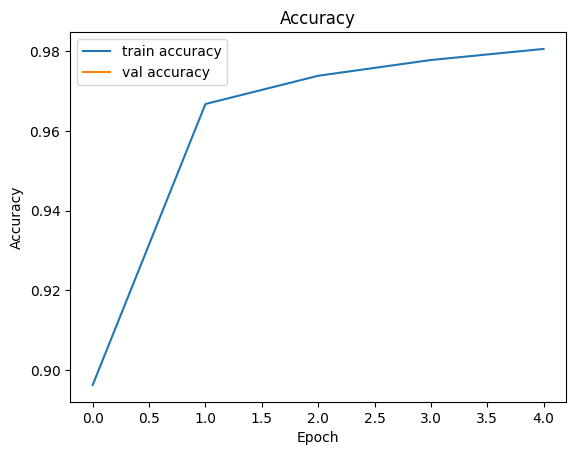

In [127]:
plt.title("Accuracy")
plt.plot(train_accuracy, label="train accuracy")
plt.plot(validation_accuracy, label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

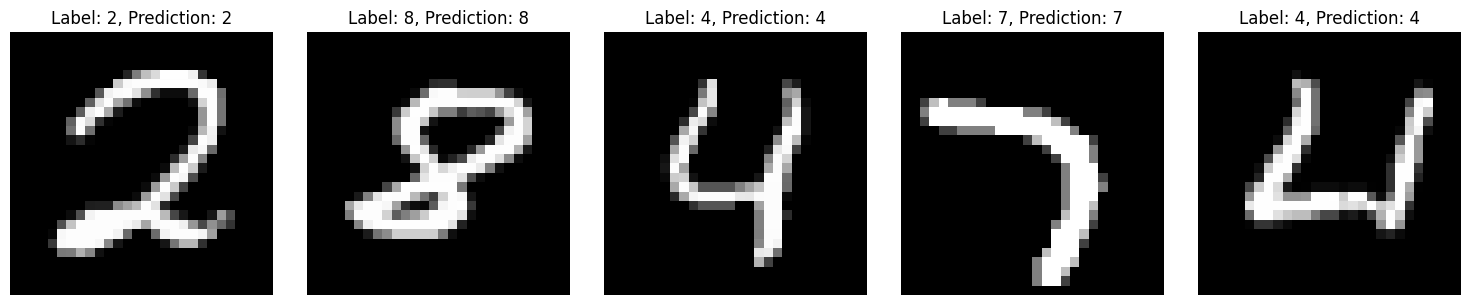

In [139]:
num_samples = 5
images, labels = next(iter(validation_set))

plt.figure(figsize=(15, 3))
for i in range(num_samples):
    index = torch.randint(len(validation_set), (1,)).item()
    image = images[index].to(device)
    label = labels[index]
    logits = model(image.unsqueeze(0))
    pred = torch.argmax(logits, dim=1)
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(images[index].squeeze(), cmap="gray")
    plt.title(f"Label: {label.item()}, Prediction: {pred.item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()
